Classification Using Artificial Neural Networks with Hyperparameter Tuning on Alphabets Data

Overview
In this assignment, you will be tasked with developing a classification model using Artificial Neural Networks (ANNs) to classify data points from the "Alphabets_data.csv" dataset into predefined categories of alphabets. This exercise aims to deepen your understanding of ANNs and the significant role hyperparameter tuning plays in enhancing model performance.

Dataset: "Alphabets_data.csv"

The dataset provided, "Alphabets_data.csv", consists of labeled data suitable for a classification task aimed at identifying different alphabets. Before using this data in your model, you'll need to preprocess it to ensure optimal performance.


Tasks

1. Data Exploration and Preprocessing

●	Begin by loading and exploring the "Alphabets_data.csv" dataset. Summarize its key features such as the number of samples, features, and classes.

●	Execute necessary data preprocessing steps including data normalization, managing missing values.


In [ ]:
#load the dataset
import pandas as pd
df=pd.read_csv('/content/Alphabets_data.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [ ]:
df.describe()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [ ]:
# checking for missing values
df.isnull().sum()

,0
letter,0
xbox,0
ybox,0
width,0
height,0
onpix,0
xbar,0
ybar,0
x2bar,0
y2bar,0


In [ ]:
# target is letter
target=df['letter']
# rest all are features
features=df.drop(columns='letter')

In [ ]:
#Normalization
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()
features=pd.DataFrame(min_max.fit_transform(features),columns=features.columns)

In [ ]:
features.head()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,0.133333,0.533333,0.2,0.333333,0.066667,0.533333,0.866667,0.000000,0.400000,0.400000,0.666667,0.533333,0.000000,0.533333,0.000000,0.533333
1,0.333333,0.800000,0.2,0.466667,0.133333,0.666667,0.333333,0.333333,0.266667,0.866667,0.200000,0.600000,0.133333,0.533333,0.266667,0.666667
2,0.266667,0.733333,0.4,0.533333,0.400000,0.666667,0.400000,0.133333,0.400000,0.666667,0.200000,0.466667,0.200000,0.466667,0.200000,0.600000
3,0.466667,0.733333,0.4,0.400000,0.200000,0.333333,0.600000,0.266667,0.400000,0.266667,0.266667,0.666667,0.400000,0.666667,0.133333,0.533333
4,0.133333,0.066667,0.2,0.066667,0.066667,0.533333,0.400000,0.400000,0.400000,0.400000,0.333333,0.600000,0.066667,0.466667,0.333333,0.666667


In [ ]:
target.head()

,letter
0,T
1,I
2,D
3,N
4,G


2. Model Implementation

●	Construct a basic ANN model using your chosen high-level neural network library. Ensure your model includes at least one hidden layer.

●	Divide the dataset into training and test sets.

●	Train your model on the training set and then use it to make predictions on the test set.


In [ ]:
!pip install keras

In [ ]:
!pip install tensorflow

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
#labelencoder
from sklearn.preprocessing import LabelEncoder
lab_enc=LabelEncoder()
target=pd.DataFrame(lab_enc.fit_transform(target))

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42, stratify=target)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16000, 16), (4000, 16), (16000, 1), (4000, 1))

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import RMSprop

In [ ]:
epochs=10
batch_size=50

In [ ]:
model=Sequential()
model.add(Dense(32,activation='relu',input_shape=(features.shape[1],)))
model.add(Dense(16,activation='relu'))
model.add(Dense(len(lab_enc.classes_),activation='softmax'))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 26)                  │             442 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,514 (5.91 KB)

 Trainable params: 1,514 (5.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=RMSprop(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=epochs,batch_size=batch_size,validation_data=(x_test,y_test))

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1170 - loss: 3.1774 - val_accuracy: 0.2447 - val_loss: 2.7949
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2780 - loss: 2.6199 - val_accuracy: 0.3783 - val_loss: 2.1899
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4063 - loss: 2.0824 - val_accuracy: 0.4480 - val_loss: 1.8729
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4620 - loss: 1.8116 - val_accuracy: 0.4935 - val_loss: 1.6890
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5106 - loss: 1.6357 - val_accuracy: 0.5425 - val_loss: 1.5687
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5396 - loss: 1.5441 - val_accuracy: 0.5702 - val_loss: 1.4881
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5726 - loss: 1.4667 - val_accuracy: 0.5885 - val_loss: 1.4287
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5919 - loss: 1.4012 - val_accuracy: 0.

In [ ]:
model.evaluate(x_test,y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6296 - loss: 1.3015


[1.303503394126892, 0.6315000057220459]

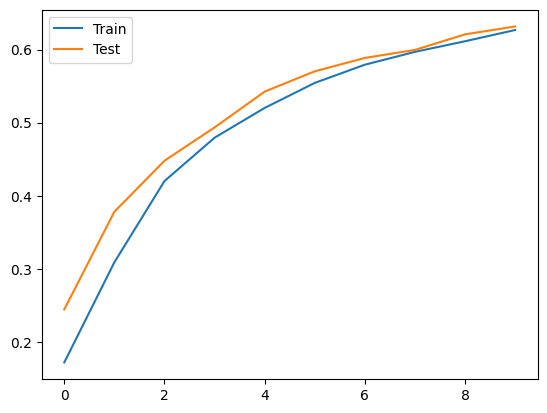

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(10),history.history['accuracy'],label='Train')
plt.plot(range(10),history.history['val_accuracy'],label='Test')
plt.legend()

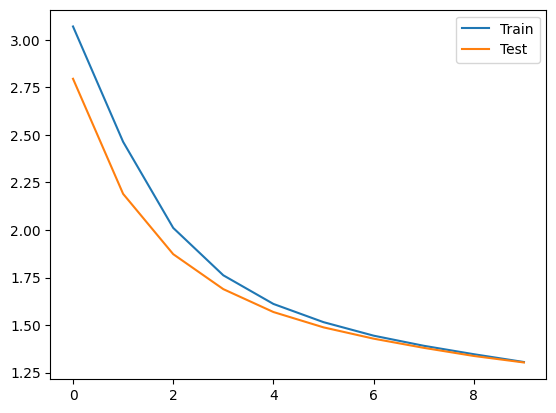

In [ ]:
plt.plot(range(10),history.history['loss'],label='Train')
plt.plot(range(10),history.history['val_loss'],label='Test')
plt.legend()

3. Hyperparameter Tuning

●	Modify various hyperparameters, such as the number of hidden layers, neurons per hidden layer, activation functions, and learning rate, to observe their impact on model performance.

●	Adopt a structured approach like grid search or random search for hyperparameter tuning, documenting your methodology thoroughly.


In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.7 MB/s eta 0:00:00


In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import keras_tuner as kt

In [31]:
def build_model(hp):
    model = Sequential()

    # Input Layer
    model.add(Dense(units=hp.Int('num_of_neurons0', min_value=32, max_value=512, step=32),
                    activation=hp.Choice('activation', ['relu', 'tanh']),
                    input_shape=(16,)))

    # Hidden Layers
    for i in range(hp.Int('num_of_layers', 2, 10)):
        model.add(Dense(units=hp.Int('num_of_neurons' + str(i), min_value=32, max_value=512, step=32),
                        activation=hp.Choice('activation', ['relu', 'tanh'])))

        model.add(Dropout(rate=hp.Choice('dropout', values=[0.1, 0.2, 0.3])))  # Dropout for regularization

    # Output Layer
    model.add(Dense(len(lab_enc.classes_), activation='softmax'))


    model.compile(optimizer=keras.optimizers.Adam(
                    hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


In [32]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=2,
    directory='hyperparameter_tuning',
    project_name='ANN_tuning'
)

Reloading Tuner from hyperparameter_tuning/ANN_tuning/tuner0.json


In [33]:
tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 5 Complete [00h 01m 18s]
val_accuracy: 0.9189999997615814

Best val_accuracy So Far: 0.9189999997615814
Total elapsed time: 00h 10m 19s


In [38]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_hps.values

{'num_of_neurons0': 224,
 'activation': 'tanh',
 'num_of_layers': 3,
 'dropout': 0.2,
 'num_of_neurons1': 128,
 'learning_rate': 0.001,
 'num_of_neurons2': 320,
 'num_of_neurons3': 192,
 'num_of_neurons4': 448,
 'num_of_neurons5': 64,
 'num_of_neurons6': 416,
 'num_of_neurons7': 288,
 'num_of_neurons8': 512}

4. Evaluation

●	Employ suitable metrics such as accuracy, precision, recall, and F1-score to evaluate your model's performance.

●	Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning


In [39]:
from sklearn.metrics import classification_report,accuracy_score

In [40]:
y_pred=model.predict(x_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [41]:
y_pred_classes = y_pred.argmax(axis=1)

In [42]:
print(classification_report(y_test,y_pred_classes))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       158
           1       0.69      0.69      0.69       153
           2       0.82      0.70      0.75       147
           3       0.54      0.65      0.59       161
           4       0.45      0.45      0.45       154
           5       0.53      0.52      0.52       155
           6       0.67      0.50      0.57       155
           7       0.40      0.21      0.28       147
           8       0.87      0.82      0.85       151
           9       0.83      0.75      0.79       149
          10       0.51      0.59      0.55       148
          11       0.87      0.80      0.83       152
          12       0.72      0.85      0.78       158
          13       0.66      0.78      0.72       157
          14       0.54      0.49      0.51       150
          15       0.68      0.71      0.70       161
          16       0.48      0.43      0.45       157
          17       0.55    

In [43]:
accuracy_score(y_test,y_pred_classes)

0.6315

In [44]:
'''
The model before hypertunning leads to overfitting.
The model after hyperfitting improves the model's performance.

The model before hypertunning has high loss.
The model after hypertunning has low loss.
'''

"\nThe model before hypertunning leads to overfitting.\nThe model after hyperfitting improves the model's performance.\n\nThe model before hypertunning has high loss.\nThe model after hypertunning has low loss.\n"